# pygeoglim — Global Geology Data Fetcher

Demonstrates how to fetch raw GLiM (lithology) and GLHYMPS (hydrogeology) polygons for any watershed on Earth, and compute CAMELS-style attribute summaries.

```bash
pip install pygeoglim geopandas matplotlib
```

In [1]:
from shapely.geometry import box
from pygeoglim import (
    fetch_glim, fetch_glhymps,
    glim_attributes, glhymps_attributes,
    decode_glim_lithology,
)

## 1. Define a watershed

Pass any `shapely` geometry in WGS-84 (lon/lat). `box(minx, miny, maxx, maxy)` is the quickest way to create a bounding-box polygon.

In [2]:
# Rhine River headwaters — Switzerland / Germany
rhine = box(6.0, 46.5, 8.5, 48.5)

# Amazon headwaters — Peru
amazon = box(-77.0, -12.0, -73.0, -8.0)

## 2. Fetch raw lithology polygons (GLiM)

In [3]:
# region='global' → downloads from the global sharded tiles
# region='auto'   → auto-detect (CONUS tile if centroid in CONUS, else global)
glim_gdf = fetch_glim(rhine, region="global")
print(glim_gdf.shape)
print(glim_gdf.columns.tolist())
glim_gdf.head()

(5672, 8)
['IDENTITY_', 'Litho', 'xx', 'Shape_Length', 'Shape_Area', 'geometry', 'pfaf2', 'cell']


,IDENTITY_,Litho,xx,Shape_Length,Shape_Area,geometry,pfaf2,cell
0,DEU16767,ssmx__,ss,1.164428e+06,8.214359e+08,"MULTIPOLYGON (((8.49512 48.48015, 8.49047 48.4...",synthetic_islands,N45_E005
1,DEU16812,ssmx__,ss,1.050535e+06,5.234712e+08,"POLYGON ((8.42598 48.49825, 8.42429 48.49713, ...",synthetic_islands,N45_E005
2,DEU16890,smmx__,sm,8.886832e+05,1.026868e+09,"POLYGON ((8.49935 47.84473, 8.49852 47.84614, ...",synthetic_islands,N45_E005
3,DEU17076,scmx__,sc,1.698765e+06,4.248577e+09,"MULTIPOLYGON (((8.39083 47.57999, 8.38726 47.5...",synthetic_islands,N45_E005
4,DEU17132,ssmx__,ss,6.958964e+05,3.386286e+08,"MULTIPOLYGON (((8.33345 48.35076, 8.33325 48.3...",synthetic_islands,N45_E005


In [4]:
# Human-readable lithology names
glim_gdf["lith_name"] = glim_gdf["xx"].map(decode_glim_lithology)
glim_gdf[["xx", "lith_name", "geometry"]].head(10)

,xx,lith_name,geometry
0,ss,Siliciclastic sedimentary rocks,"MULTIPOLYGON (((8.49512 48.48015, 8.49047 48.4..."
1,ss,Siliciclastic sedimentary rocks,"POLYGON ((8.42598 48.49825, 8.42429 48.49713, ..."
2,sm,Mixed sedimentary rocks,"POLYGON ((8.49935 47.84473, 8.49852 47.84614, ..."
3,sc,Carbonate sedimentary rocks,"MULTIPOLYGON (((8.39083 47.57999, 8.38726 47.5..."
4,ss,Siliciclastic sedimentary rocks,"MULTIPOLYGON (((8.33345 48.35076, 8.33325 48.3..."
5,sc,Carbonate sedimentary rocks,"MULTIPOLYGON (((8.49809 48.06428, 8.49621 48.0..."
6,pa,Acid plutonic rocks,"POLYGON ((8.14477 48.49982, 8.1433 48.49911, 8..."
7,mt,Metamorphics,"POLYGON ((8.37602 48.49818, 8.37583 48.49392, ..."
8,sm,Mixed sedimentary rocks,"POLYGON ((8.00227 48.49899, 7.99454 48.48982, ..."
9,pa,Acid plutonic rocks,"MULTIPOLYGON (((8.16909 48.49933, 8.16383 48.4..."


## 3. Fetch raw hydrogeology polygons (GLHYMPS)

In [5]:
glhymps_gdf = fetch_glhymps(rhine, region="global")
print(glhymps_gdf.shape)
print(glhymps_gdf.columns.tolist())
glhymps_gdf.head()

(9509, 26)
['OBJECTID_1', 'IDENTITY_', 'logK_Ice_x', 'logK_Ferr_', 'Porosity_x', 'K_stdev_x1', 'OBJECTID', 'Descriptio', 'XX', 'YY', 'ZZ', 'AA', 'DD', 'Shape_Leng', 'GUM_K', 'Prmfrst', 'Shape_Le_1', 'Shape_Area', 'Transmissi', 'COUNT', 'AREA_1', 'MEAN', 'STD', 'geometry', 'pfaf2', 'cell']


,OBJECTID_1,IDENTITY_,logK_Ice_x,logK_Ferr_,Porosity_x,K_stdev_x1,OBJECTID,Descriptio,XX,YY,...,Shape_Le_1,Shape_Area,Transmissi,COUNT,AREA_1,MEAN,STD,geometry,pfaf2,cell
0,1220607,DEU17689,-1410,-1410,1,150,0,None,None,None,...,218483.544358,1.161086e+08,0.0,0,0.0,0.0,0.0,"MULTIPOLYGON (((8.00276 48.43042, 8.00269 48.4...",synthetic_islands,N45_E005
1,1220632,DEU17771,-1410,-1410,1,150,0,None,None,None,...,70425.531799,1.938041e+07,0.0,0,0.0,0.0,0.0,"POLYGON ((8.37602 48.49818, 8.37583 48.49392, ...",synthetic_islands,N45_E005
2,1220651,DEU17835,-1520,-1520,19,250,0,None,None,None,...,8802.737863,8.404492e+05,0.0,0,0.0,0.0,0.0,"MULTIPOLYGON (((7.98745 48.48197, 7.9877 48.48...",synthetic_islands,N45_E005
3,1220672,DEU17884,-1410,-1410,1,150,0,None,None,None,...,27145.867340,1.853129e+07,0.0,0,0.0,0.0,0.0,"MULTIPOLYGON (((8.16909 48.49933, 8.16383 48.4...",synthetic_islands,N45_E005
4,1220704,DEU17959,-1410,-1410,1,150,0,None,None,None,...,25690.204467,4.556984e+06,0.0,0,0.0,0.0,0.0,"POLYGON ((8.31773 48.49897, 8.3152 48.49742, 8...",synthetic_islands,N45_E005


## 4. CAMELS-style attribute summaries

In [6]:
glim_attrs = glim_attributes(glim_gdf)
glim_attrs

{'geol_1st_class': 'Carbonate sedimentary rocks — Fine grained (shale)',
 'glim_1st_class_frac': 0.1380865341582217,
 'geol_2nd_class': 'Mixed sedimentary rocks — Mixed grain size',
 'glim_2nd_class_frac': 0.13127255481274247,
 'carbonate_rocks_frac': 0.31836608797357685}

In [7]:
glhymps_attrs = glhymps_attributes(glhymps_gdf)
glhymps_attrs

{'geol_porosity': 0.06659616776877143,
 'geol_permeability': -11.335863477124008,
 'geol_permeability_linear': 4.614626150911851e-12,
 'hydraulic_conductivity': 4.614626150911851e-05}

## 5. Visualise lithology map

/var/folders/ns/7gh688vn04x1rtn_tsr23pmm0000gn/T/ipykernel_33230/2655278289.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(lith_classes))


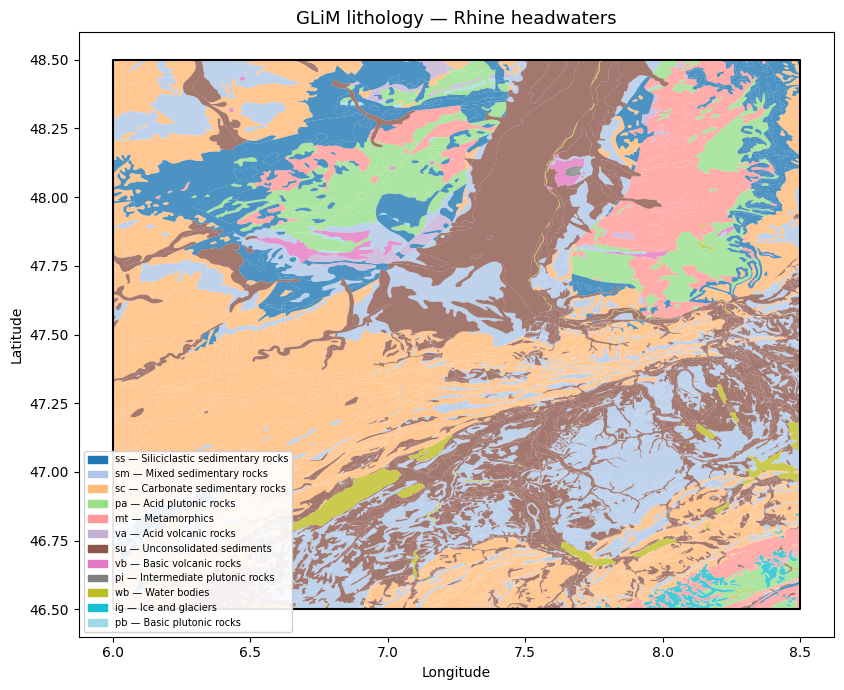

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(9, 7))

# Colour each lithology class distinctly
lith_classes = glim_gdf["xx"].unique()
cmap = plt.cm.get_cmap("tab20", len(lith_classes))
colour_map = {cls: cmap(i) for i, cls in enumerate(lith_classes)}

for cls, grp in glim_gdf.groupby("xx"):
    grp.plot(ax=ax, color=colour_map[cls], edgecolor="none", alpha=0.8)

# Watershed outline
import geopandas as gpd
gpd.GeoSeries([rhine]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)

# Legend
patches = [
    mpatches.Patch(color=colour_map[c], label=f"{c} — {decode_glim_lithology(c)}")
    for c in lith_classes
]
ax.legend(handles=patches, fontsize=7, loc="lower left", framealpha=0.9)
ax.set_title("GLiM lithology — Rhine headwaters", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 6. Visualise permeability

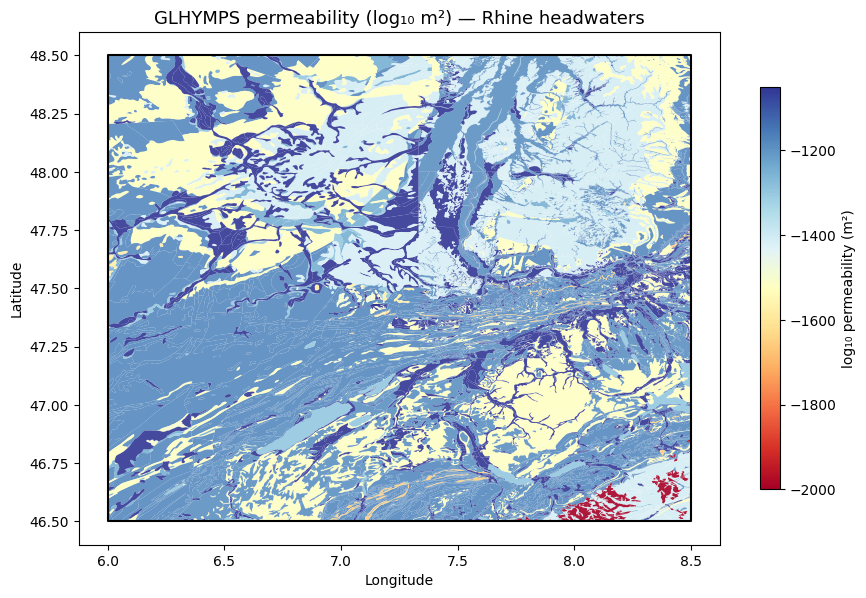

In [9]:
fig, ax = plt.subplots(figsize=(9, 7))

glhymps_gdf.plot(
    column="logK_Ice_x",
    ax=ax,
    cmap="RdYlBu",
    legend=True,
    legend_kwds={"label": "log₁₀ permeability (m²)", "shrink": 0.6},
    edgecolor="none",
    alpha=0.9,
)
gpd.GeoSeries([rhine]).plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.5)
ax.set_title("GLHYMPS permeability (log₁₀ m²) — Rhine headwaters", fontsize=13)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

## 7. Multi-basin batch

Run for several watersheds and collect results into a single attribute table.

In [10]:
import pandas as pd

basins = {
    "Rhine (Germany)":   box(6.0,  46.5, 8.5,  48.5),
    "Amazon headwaters": box(-77.0, -12.0, -73.0, -8.0),
    "Ganges (India)":    box(77.0,  25.0, 83.0,  29.0),
    "Mississippi (CONUS)": box(-93.0, 36.0, -88.0, 41.0),
}

rows = []
for name, geom in basins.items():
    glim_g   = fetch_glim(geom, region="auto")
    glhymps_g = fetch_glhymps(geom, region="auto")
    row = {"basin": name}
    row.update(glim_attributes(glim_g))
    row.update(glhymps_attributes(glhymps_g))
    rows.append(row)
    print(f"  ✓ {name}")

df = pd.DataFrame(rows).set_index("basin")
df

  ✓ Rhine (Germany)
  ✓ Amazon headwaters
  ✓ Ganges (India)
  ✓ Mississippi (CONUS)


,geol_1st_class,glim_1st_class_frac,geol_2nd_class,glim_2nd_class_frac,carbonate_rocks_frac,geol_porosity,geol_permeability,geol_permeability_linear,hydraulic_conductivity
basin,,,,,,,,,
Rhine (Germany),Carbonate sedimentary rocks — Fine grained (sh...,0.138087,Mixed sedimentary rocks — Mixed grain size,0.131273,0.318366,0.066596,-11.335863,4.614626e-12,0.000046
Amazon headwaters,Mixed sedimentary rocks — Pyroclastics present...,0.177820,Unconsolidated sediments — Mixed grain size — ...,0.173641,0.109609,0.098251,-11.152447,7.039686e-12,0.000070
Ganges (India),Unconsolidated sediments — Mixed grain size,0.746889,Acid plutonic rocks,0.068710,0.000000,0.024275,-10.632774,2.329302e-11,0.000233
Mississippi (CONUS),Siliciclastic sedimentary rocks — Mixed grain ...,0.229538,Carbonate sedimentary rocks — Fine grained (sh...,0.169185,0.452354,0.015889,-11.555635,2.782050e-12,0.000028
